# Bringing your own data to TetrisCNN

TetrisCNN asks very little of a dataset. It needs **spin snapshots** on a lattice (values
$\pm1$, one image channel per measurement basis), and for every snapshot the **value of the
tuning parameter** at which it was taken. Everything else, including the train/validation
split, balancing across the sweep, training, and the per-branch readout, is shared machinery
that works the same for every data source.

This notebook walks through the full route for a dataset the library has never seen:

1. **The data.** A small synthetic "experiment" is written to disk in a format of its own,
   standing in for the files you would get from a lab or a simulation code.
2. **A processor.** A short class that reads those files and hands TetrisCNN its snapshots.
   This is the only part that depends on your file format.
3. **Registration.** One call, `register_dataset`, makes the new data selectable by name
   (`cf.dataset = "NeelFlips"`), exactly like the built-in Rydberg datasets.
4. **Training.** The standard training loop, `tetriscnn.train.train`, run unchanged.
5. **Reading the result.** Which branches survived the sparsity penalty, and what their
   activations measure in terms of spin correlators.

The toy data is chosen so that the last step has a definite answer. You can therefore
check that the pipeline recovers the physics that was put in, before trusting it on data
where the answer is unknown. Nothing needs to be downloaded, and the whole notebook runs in
under a minute on a laptop.

In [1]:
# tetriscnn is imported before numpy/torch on purpose: on macOS it sets the OpenMP
# environment variables that let conda's numpy and pip's torch share one process.
import tetriscnn
from tetriscnn.datasets import create_datasets, register_dataset
from tetriscnn.dataprocessing import SnapshotProcessor
from tetriscnn.interpret import fit_activation_to_correlators
from tetriscnn.models import ShapeAdaptiveConvNet
from tetriscnn.train import train
from tetriscnn.utils import (
    AttrDict, DEVICE, load_json, set_kernels, set_plotting_logging_strings,
)

import contextlib
import io
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Math, display, Pretty, Markdown

print("device:", DEVICE)

device: mps


## 1. The data: a Néel antiferromagnet with random spin flips

The toy system is an $8\times8$ square lattice in a checkerboard (Néel) state. Each spin is
flipped independently with probability $p$, which plays the role of the tuning parameter and
is swept over eleven values from $p=0$ (perfect order) to $p=0.5$ (a fully random
configuration). Every snapshot also receives a random global sign, as a real
antiferromagnet picks one of its two degenerate ground states at random.

This model is useful because it makes the correlator content of each phase explicit:

* the **magnetization** $C[\blacksquare] = \langle S_i \rangle$ averages to zero at every $p$, so a
  single-site pattern cannot distinguish order from disorder;
* the **nearest-neighbour correlator** $C[\blacksquare\blacksquare] = \langle S_i S_{i+\hat x}\rangle$ equals
  $-(1-2p)^2$ and the **diagonal correlator** equals $+(1-2p)^2$, so every two-site pattern
  measures the order directly.

A network that has learned the task should therefore rely on two-site branches, and ignore
the single-site branch as well as the larger patterns, which carry no additional
information.

The files imitate how such data typically arrives: one file per sweep point, the tuning
parameter encoded in the file name, and the spins stored as $0/1$ occupations (the native
output of a Rydberg or quantum-gas microscope) rather than as $\pm1$.

In [2]:
L = 8                                          # lattice side
num_pts = 11
P_VALUES = np.round(np.linspace(0.0, 0.5, num_pts), 2)
SNAPSHOTS_PER_POINT = 500
P_CRITICAL = 0.25                              # the classification boundary used below

data_dir = Path(tempfile.mkdtemp(prefix="neel_flips_")) # <<<<<< Replace this with a path to your own directory if you want to keep the generated data files.
rng = np.random.default_rng(0)
checkerboard = np.indices((L, L)).sum(axis=0) % 2

for p in P_VALUES:
    global_sign = rng.integers(0, 2, size=(SNAPSHOTS_PER_POINT, 1, 1))
    flips = rng.random((SNAPSHOTS_PER_POINT, L, L)) < p
    occupations = (checkerboard ^ global_sign ^ flips).astype(np.uint8)   # 0/1, shape (snapshots, L, L)
    np.save(data_dir / f"snapshots_p={p:.2f}.npy", occupations)

print(f"wrote {len(P_VALUES)} files to {data_dir}")
print(sorted(f.name for f in data_dir.iterdir())[:3], "...")

wrote 11 files to /var/folders/ny/xk8kjhk1187_wmh8cphjtsz80000gn/T/neel_flips_zln7nalg
['snapshots_p=0.00.npy', 'snapshots_p=0.05.npy', 'snapshots_p=0.10.npy'] ...


Before involving any network, it is worth looking at the data and measuring the quantities
the model is expected to find. The two correlators below are the ground truth that step 5
should recover.

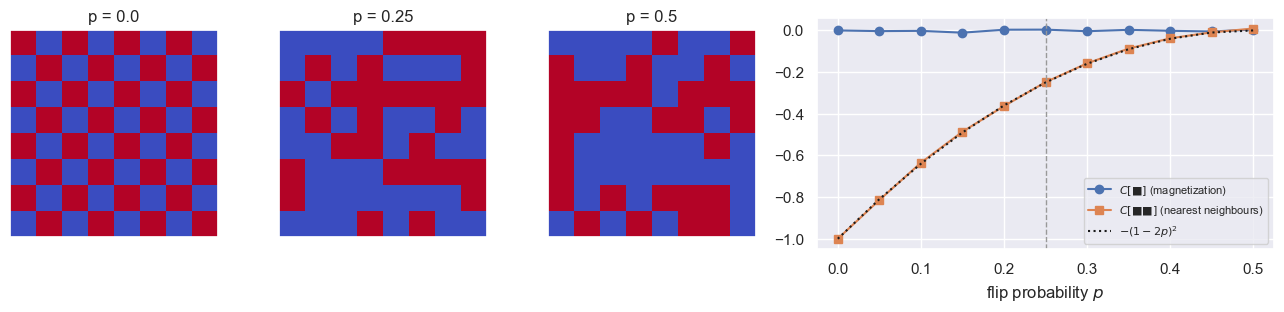

In [3]:
def load_spins(p):
    return 2.0 * np.load(data_dir / f"snapshots_p={p:.2f}.npy").astype(np.float32) - 1.0

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), gridspec_kw={"width_ratios": [1, 1, 1, 2.2]})
for ax, p in zip(axes[:3], (P_VALUES[0], P_VALUES[num_pts//2], P_VALUES[-1])):
    ax.imshow(load_spins(p)[0], cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"p = {p}")
    ax.set_xticks([]); ax.set_yticks([])

magnetization = [load_spins(p).mean() for p in P_VALUES]
nn_correlator = [(load_spins(p)[:, :, :-1] * load_spins(p)[:, :, 1:]).mean() for p in P_VALUES]
ax = axes[3]
ax.plot(P_VALUES, magnetization, "o-", label=r"$C[\blacksquare]$ (magnetization)")
ax.plot(P_VALUES, nn_correlator, "s-", label=r"$C[\blacksquare\blacksquare]$ (nearest neighbours)")
ax.plot(P_VALUES, -(1 - 2 * P_VALUES) ** 2, "k:", label=r"$-(1-2p)^2$")
ax.axvline(P_CRITICAL, color="0.6", ls="--", lw=1)
ax.set_xlabel("flip probability $p$")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2. A processor: turning files into snapshots

`create_datasets()` never opens a file itself. It asks a *processor* object for the
snapshots, then does the splitting, balancing, and label handling in one shared place.
Once constructed, a processor exposes

| attribute | what it holds |
| --- | --- |
| `samples` | a list of `(snapshot, label)` pairs. `snapshot` is a `float32` tensor of shape `(C, H, W)` with values $\pm1$; `C` is the number of measurement bases (1 here, 2 for the X+Z Rydberg data). `label` is a `float32` scalar tensor. |
| `sample_times` | the tuning-parameter value of each snapshot, in the same order. This is what `even_split` balances over, and what every per-sweep-point average in the library is taken over. The name is historical: for the Rydberg data the tuning parameter is the acquisition time. |
| `unique_labels`, `label_param` | the distinct values of the tuning parameter, and its name. |

Data that comes as *a set of snapshots for each value of the tuning parameter* (the Rydberg
data, and most sweeps) does not need any of this written by hand.
`tetriscnn.dataprocessing.SnapshotProcessor` builds these attributes for you, and the
Rydberg loaders are subclasses of it. It stacks several measurement bases into channels,
maps stored $0/1$ values to $\pm1$, and assigns the label the task asks for, which
`create_datasets()` passes in as `discrete_labels` and `learning_by_confusion`:

* **regression**: the tuning parameter itself, so the network learns to estimate $p$;
* **learning by confusion** (`task="partition"` or `"lbc"`): the true phase is treated as
  unknown, and snapshots are labelled `0`/`1` on either side of a trial threshold between
  two neighbouring sweep points. This is how the manuscript treats experimental data, which
  has no ground-truth phase;
* **classification**: the known phase at each $p$, which only your subclass can supply,
  through `_phase_label(p)`.

A subclass therefore only describes the file format. It passes the list of files per basis
and the lattice shape to the base class, and implements `_load_basis_files`, which returns
`{p: array}` with one snapshot per row. The base class reshapes each row to the lattice; a
format that needs more than a reshape (the Rydberg files are also rotated to the atom
layout) overrides `_to_image` as well.

In [4]:
class NeelFlipsProcessor(SnapshotProcessor):
    def __init__(self, directory, discrete_labels=False, learning_by_confusion=False, partition_index=None):
        files = sorted(Path(directory).glob("snapshots_p=*.npy"))
        super().__init__(
            grid_size=(L, L),
            label_param="p",
            file_dict={"Z": files},       # one entry per measurement basis
            data_format="-11",            # the files hold 0/1; the base class maps them to ±1
            discrete_labels=discrete_labels,
            learning_by_confusion=learning_by_confusion,
            partition_index=partition_index,
        )

    def _load_basis_files(self, file_list):
        # format-specific: one .npy file per value of p, the value encoded in the file name,
        # each holding an array of shape (snapshots, L, L)
        return {float(path.stem.split("=")[1]): np.load(path).astype(np.float32)
                for path in file_list}

    def _phase_label(self, p):
        # the known phase boundary, used only for plain classification
        return int(p > P_CRITICAL)

The processor can be tested on its own before it goes anywhere near a network. The things to
check are the snapshot shape and value range, and that the labels and the sweep came out as
intended: with `discrete_labels=True` the labels are the phases, 0 and 1.

In [5]:
proc = NeelFlipsProcessor(data_dir, discrete_labels=True)
x0, y0 = proc.samples[0]
print(f"{len(proc.samples)} snapshots, shape {tuple(x0.shape)}, values {torch.unique(x0).tolist()}")
labels = sorted({float(label) for _, label in proc.samples})
print(f"labels: {labels}   sweep: {sorted(set(proc.sample_times))}")

5500 snapshots, shape (1, 8, 8), values [-1.0, 1.0]
labels: [0.0, 1.0]   sweep: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


## 3. Registering the dataset

`create_datasets(cf)` selects its data source by name, from `cf.dataset`.
`register_dataset(name, factory)` adds a name to that lookup. The factory receives the full
config `cf`, so any option your processor needs (here, the data directory) can travel in the
config alongside the standard settings, and is saved with every run in its `config.json`. It
also receives the label settings that `create_datasets()` has already derived from
`cf.task`, so the factory only has to pass them on.

The registration has to run in the same Python process as the training. In a notebook this
cell does that. For a script, put the call before training starts, for instance near the
top of a copy of `main.py`.

In [6]:
def make_neel_flips(cf, *, discrete_labels, label_param, learning_by_confusion, partition_index):
    return NeelFlipsProcessor(cf.data_dir, discrete_labels, learning_by_confusion, partition_index)

register_dataset("NeelFlips", make_neel_flips)

cf = AttrDict()
cf.dataset = "NeelFlips"
cf.data_dir = str(data_dir)
cf.task = "classification"          # or "regression" (learn p itself) / "partition" (+ cf.partition_index)
cf.label_param = "p"

cf.train_dataset, cf.val_dataset = create_datasets(cf)
print(f"\ntrain: {len(cf.train_dataset)}  val: {len(cf.val_dataset)}  "
      f"output_dim: {cf.train_dataset.output_dim}")


[Even Split] Found 11 time points
[Even Split] Samples per time point: min=500, max=500, median=500.0
[Even Split] After per-time-point 70/30 split: 3850 train, 1650 val samples
times shape: 3850, labels shape: torch.Size([3850])


times shape: 1650, labels shape: torch.Size([1650])

train: 3850  val: 1650  output_dim: 2


With `even_split=True`, each of the eleven sweep points contributes the same fraction of its
snapshots to training and to validation. This matters for experimental data, where the
number of snapshots usually varies strongly across the sweep (see the data-preparation
appendix of the manuscript); for this balanced toy set it simply gives $350+150$ snapshots per
point.

## 4. Training

From here on nothing is specific to the new dataset. The configuration below is a reduced
version of `setup_experiment()` in `main.py`, grouped by what each part controls. Every
option is described in [`docs/CONFIGURATION.md`](../docs/CONFIGURATION.md).

The part that makes TetrisCNN interpretable is the **L1 penalty on the bottleneck**. Each
branch $k$ produces one scalar $z_k$, and the loss contains $\sum_k \lambda_k |z_k|$. The
penalty grows with the size of the branch's pattern, from $10^{-3}$ for a single site up to
$10^{\lambda_{\max}}$ for the full $2\times2$ block (`penalty_params = [base, min exponent,
λmax, 1]`). A branch therefore stays active only if the information it carries is worth
its price, and the surviving branches mark the smallest correlators that solve the task.

In [7]:
# architecture: the ten "smallkernels" branches used throughout the manuscript
cf.model = "tetriscnn"
cf.kernel_set = "smallkernels"
cf.equivariant = True
cf.equivariant_group = "C4"
cf.hidden_size = 32
cf.init = "kaiming"
set_kernels(cf)

# sparsity: penalties from 10^-3 (one site) to 10^3 (four sites)
cf.experiment_name = "singlerun"
cf.penalty_params = [10, -3, 3, 1]

# optimisation
cf.epochs = 200
cf.batch_size = 64
cf.learning_rate = 1e-2       # This is a good starting point for the learning rate if we use this learning scheduler

cf.patience = 5
cf.early_stop_warmup = 150           # let the penalty act before early stopping may end the run
cf.early_stop_min_delta = 1e-5

cf.use_lr_scheduler = True
cf.lr_scheduler_type = "reduce_on_plateau"  # "reduce_on_plateau" | "cosine_annealing" | "step" | "exponential" | "onecycle"
cf.lr_reduce_factor = 0.5      # multiply LR by this when a plateau is detected (0.5 = halve LR)
cf.lr_reduce_patience = 5      # epochs to wait before reducing LR
cf.min_lr = 1e-9               # minimum learning rate (stop reducing below this)

cf.seed = 2137

# bookkeeping: where the run is written, and what is saved there
cf.logdir = str(Path(tempfile.mkdtemp(prefix="neel_flips_run_")) / "run") # <<<<<< Replace this with a path to your own directory if you want to keep the trained model and the training history.
cf.save_models = True
cf.save_histories = True
cf.save_final_values = False
set_plotting_logging_strings(cf)

train(cf, "metrics.json")
summary = ("Early stopping", "Branch w. largest", "Training time")


TRAINING /var/folders/ny/xk8kjhk1187_wmh8cphjtsz80000gn/T/neel_flips_run_rpoxgej5/run: --seed 2137 --device mps

{'batch_size': 64,
 'branch_groups': None,
 'branch_orbit_sizes': None,
 'data_dir': '/var/folders/ny/xk8kjhk1187_wmh8cphjtsz80000gn/T/neel_flips_zln7nalg',
 'data_fraction': 1,
 'dataset': 'NeelFlips',
 'early_stop_min_delta': 1e-05,
 'early_stop_warmup': 150,
 'epochs': 200,
 'equivariant': True,
 'equivariant_group': 'C4',
 'even_split': True,
 'experiment_name': 'singlerun',
 'filter_t_values': None,
 'goodness_str': 'acc',
 'hidden_size': 32,
 'init': 'kaiming',
 'kernel_set': 'smallkernels',
 'kernels': [[(1, 1), 1, 1, None, 1],
             [(2, 1), 1, 1, None, 1],
             [(2, 2), 1, 1, [[1, 0], [0, 1]], 1],
             [(2, 2), 1, 1, [[1, 1], [1, 0]], 1],
             [(2, 2), 1, 1, None, 1]],
 'label_param': 'p',
 'label_subset_count': None,
 'learning_rate': 0.01,
 'logdir': PosixPath('/var/folders/ny/xk8kjhk1187_wmh8cphjtsz80000gn/T/neel_flips_run_rpoxgej5

Using LR scheduler: reduce_on_plateau
penalties: [1.e-03 1.e-01 1.e-01 1.e+01 1.e+03]

Training for 200 epochs with 61 training batches and 1 validation batches.
Early stopping warmup: 150 epochs (monitoring disabled)
Early stopping patience: 5 epochs



  0%|          | 0/200 [00:00<?, ?it/s]

TRAINING:   0%|          | 0/200 [00:01<?, ?it/s]

TRAINING:   0%|          | 0/200 [00:01<?, ?it/s, TRAIN CEL=6.35e-01, TRAIN acc=0.59, VAL CEL=4.07e-01, VAL acc=0.84, LR=1.00e-02]

...

TRAINING:  89%|████████▉ | 178/200 [02:12<00:15,  1.39it/s, TRAIN CEL=2.13e-01, TRAIN acc=0.91, VAL CEL=2.16e-01, VAL acc=0.91, LR=1.91e-08]

TRAINING:  89%|████████▉ | 178/200 [02:12<00:15,  1.39it/s, TRAIN CEL=2.13e-01, TRAIN acc=0.91, VAL CEL=2.16e-01, VAL acc=0.91, LR=1.91e-08]

TRAINING:  89%|████████▉ | 178/200 [02:12<00:15,  1.39it/s, TRAIN CEL=2.13e-01, TRAIN acc=0.91, VAL CEL=2.16e-01, VAL acc=0.91, LR=1.91e-08]

TRAINING:  89%|████████▉ | 178/200 [02:12<00:16,  1.34it/s, TRAIN CEL=2.13e-01, TRAIN acc=0.91, VAL CEL=2.16e-01, VAL acc=0.91, LR=1.91e-08]

Validation objective increased (2.28e-01 --> 2.28e-01). Counter: 5 out of 5.

Early stopping at epoch 179
Branch w. largest bottleneck activation: index 1, kernel [(2, 1), 1, 1, None, 1]

Training time: ['0:02:15.170541']


`train()` writes everything a later analysis needs into `cf.logdir`: the configuration
(`config.json`), the per-epoch history including each branch's mean activation
(`metrics.json`), and the two networks (`net1.pt`, the branches, and `net2.pt`, the small
classifier head). This is the same layout as the recorded runs in `Plots_data/` that the
figure notebooks read.

## 5. Reading the result

### How training went

`plot_history` draws the curves recorded in `metrics.json`: the classification loss and
the L1 penalty term (train and validation), the accuracy, and, on a logarithmic scale, the
mean activation $|z_k|$ of every branch together with the learning rate (dashed black line).


In [8]:
metrics = load_json(cf.logdir, "metrics.json")

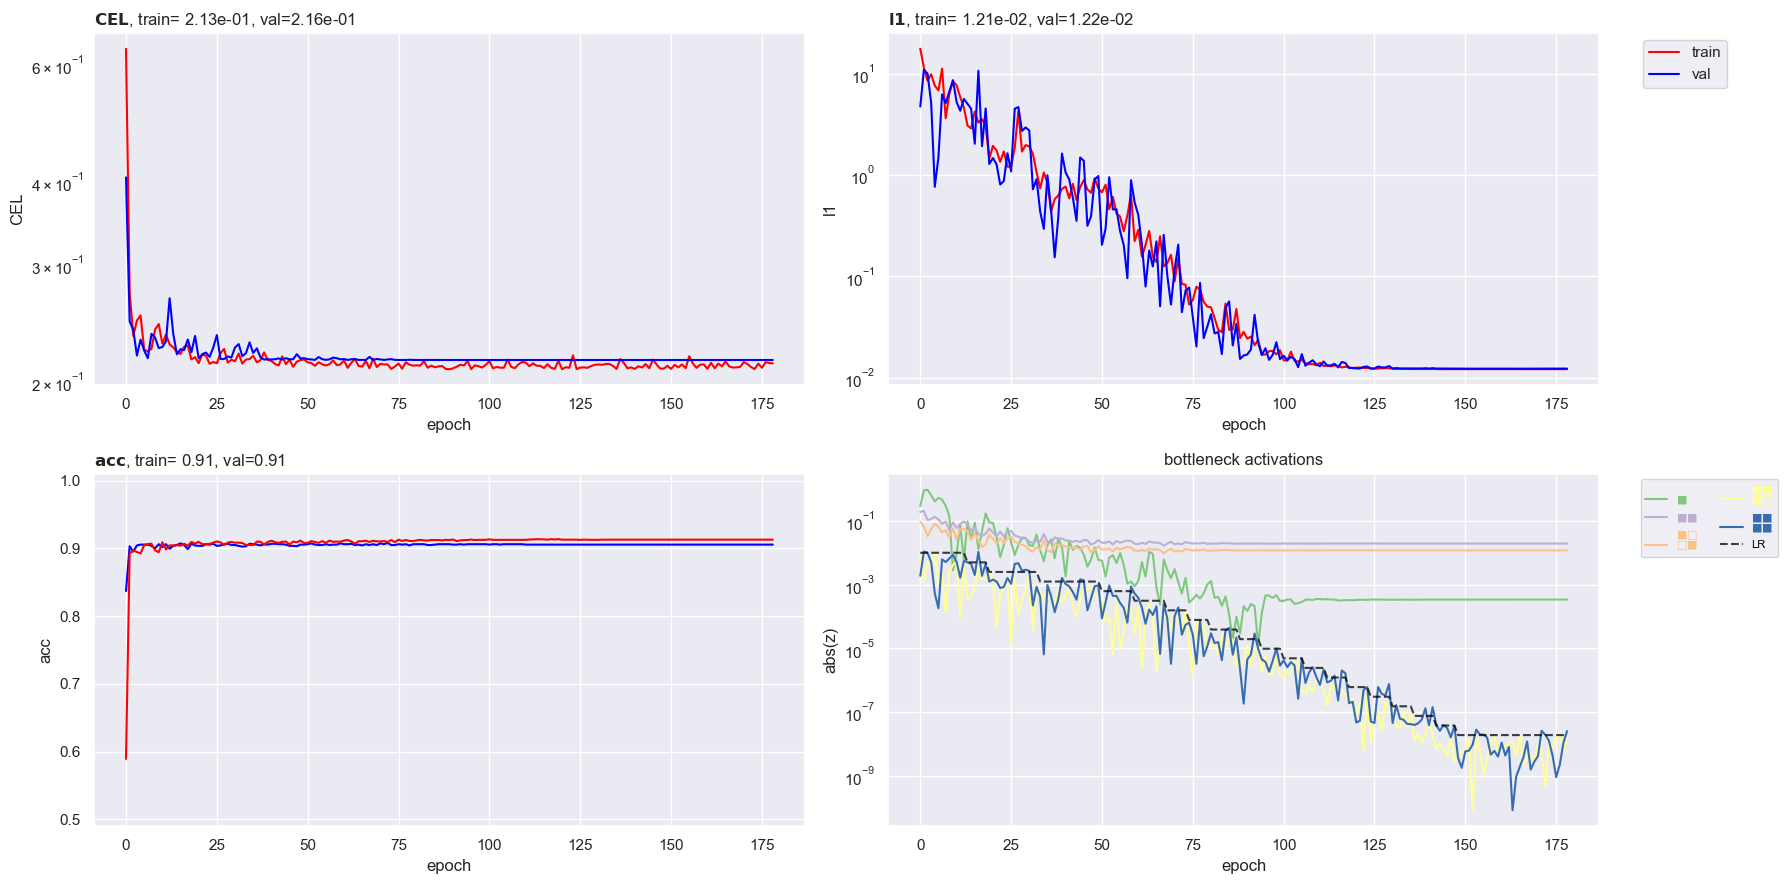

In [9]:
tetriscnn.plots.plot_history(metrics, cf, "history.png", show_dont_save=True)

The activation panel is the one to read. The branches that carry the model separate from
the others early and stay at a roughly constant level. The rest keep falling, and they fall
*with the learning rate*: every time the scheduler halves it, their activations drop by a
similar factor.

This is why learning-rate scheduling is required rather than optional. A branch the penalty
has switched off does not reach exactly zero: each optimiser step pushes it back towards zero
and the data-fit gradient pushes it away again, so it settles at a residual level of the
order of the learning rate itself, largely independent of its own penalty (see the appendix
on bottleneck optimisation and learning-rate scheduling). At a fixed learning rate of
$10^{-2}$ that floor is not far below the active branches, and "switched off" cannot be told
apart from "weakly used". Decaying the learning rate lowers the floor by orders of magnitude,
and the gap between active and inactive branches becomes unambiguous.


### Which branches survived

The final mean $|z_k|$ of each branch is its importance: a branch the penalty has switched
off contributes nothing to the prediction, whatever its weights are. The bars below use the
same pattern labels as the legend above, coloured by how many sites the pattern reads.


validation accuracy: 0.905


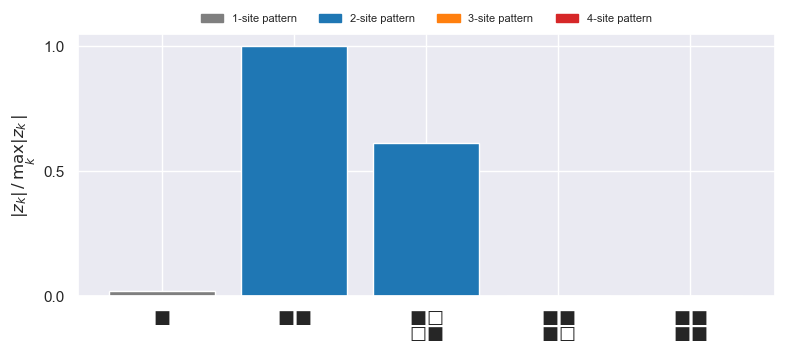

In [10]:
from tetriscnn.utils import branch_label

importance = np.array([abs(metrics[f"z_{k}"][-1]) for k in range(len(cf.kernels))])
print(f"validation accuracy: {metrics['val_acc'][-1]:.3f}")

def footprint(kernel):
    (h, w), mask = kernel[0], kernel[3]
    return np.ones((h, w)) if mask is None else np.array(mask)

order = np.array([int(footprint(k).sum()) for k in cf.kernels])   # number of sites read
colors = {1: "tab:gray", 2: "tab:blue", 3: "tab:orange", 4: "tab:red"}

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(range(len(cf.kernels)), importance / importance.max(), color=[colors[o] for o in order])
ax.set_xticks(range(len(cf.kernels)))
ax.set_xticklabels([branch_label(cf, k) for k in range(len(cf.kernels))], fontsize=13)
ax.set_yticks([0, 0.5, 1])
ax.set_ylabel(r"$|z_k|\,/\,\max_k |z_k|$")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()],
          labels=[f"{o}-site pattern" for o in colors], fontsize=8, ncol=4,
          loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False)
plt.show()


The outcome matches what the data was built to contain. With `cf.equivariant = True`, each
branch reads the average of its pattern over the four lattice rotations ($C_4$), so the
ten `smallkernels` patterns reduce to five branches: a single site, the nearest-neighbour
pair, the diagonal pair, the three-site L shape, and the full $2\times2$ plaquette.

* The **two-site** branches carry the model. The Néel order shows up in both of their
  correlators, $C[\blacksquare\blacksquare] = -(1-2p)^2$ for nearest neighbours and
  $+(1-2p)^2$ for the diagonal, so both stay active. How the activity is split between them
  changes with the seed while the accuracy does not. This is the "branches change, accuracy
  does not" behaviour discussed in the manuscript: sparsity selects a *class* of sufficient
  correlators, not one privileged network.
* The **single-site** branch is small, a few percent of the strongest, even though it is the
  cheapest. The magnetization averages to zero on both sides of the boundary, so it carries
  little information. What the branch retains comes from the magnetization of individual
  snapshots, which fluctuates slightly differently in the two phases.
* The **three- and four-site** branches are switched off: they could represent the same
  correlations, but at a higher price.

The validation accuracy stays around 90% rather than 100% because snapshots near $p_c$ are
genuinely ambiguous: at $p=0.2$ and $p=0.3$ the correlator distributions of single
$8\times8$ snapshots overlap.

### What the active branches measure

The claim that a branch "uses a correlator" can be checked directly. A branch reads the spins
under its pattern, applies the same function at every lattice position, and averages. For
$\pm1$ spins any such function is a polynomial in the spins under the pattern, so the
branch's activation is an exact linear combination of the correlators of the pattern's
sub-patterns (see the Boolean-Fourier section of the manuscript). For a two-site pattern this dictionary has
three entries: the magnetization on each of the two sites and their product. For an
equivariant branch every entry is additionally averaged over the rotations, which is why the
fit below is given the symmetry group.

The cell below first selects the **active** branches, those whose activation stays well above
the learning-rate floor discussed earlier (by default a factor $10^3$ above the final learning
rate). It then plots the complete coefficient spectrum $c_P$ of every active branch, as in the
appendix version of `Figure5.ipynb`, with the full fitted equation as the panel title. All three fits are exact, $R^2 = 1$, as the argument requires.


Using C4-equivariant convolutional branches.
final learning rate 1.9e-08; active branches: [0, 1, 2]; strongest: 1


<repo>/tetriscnn/plots.py:298: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


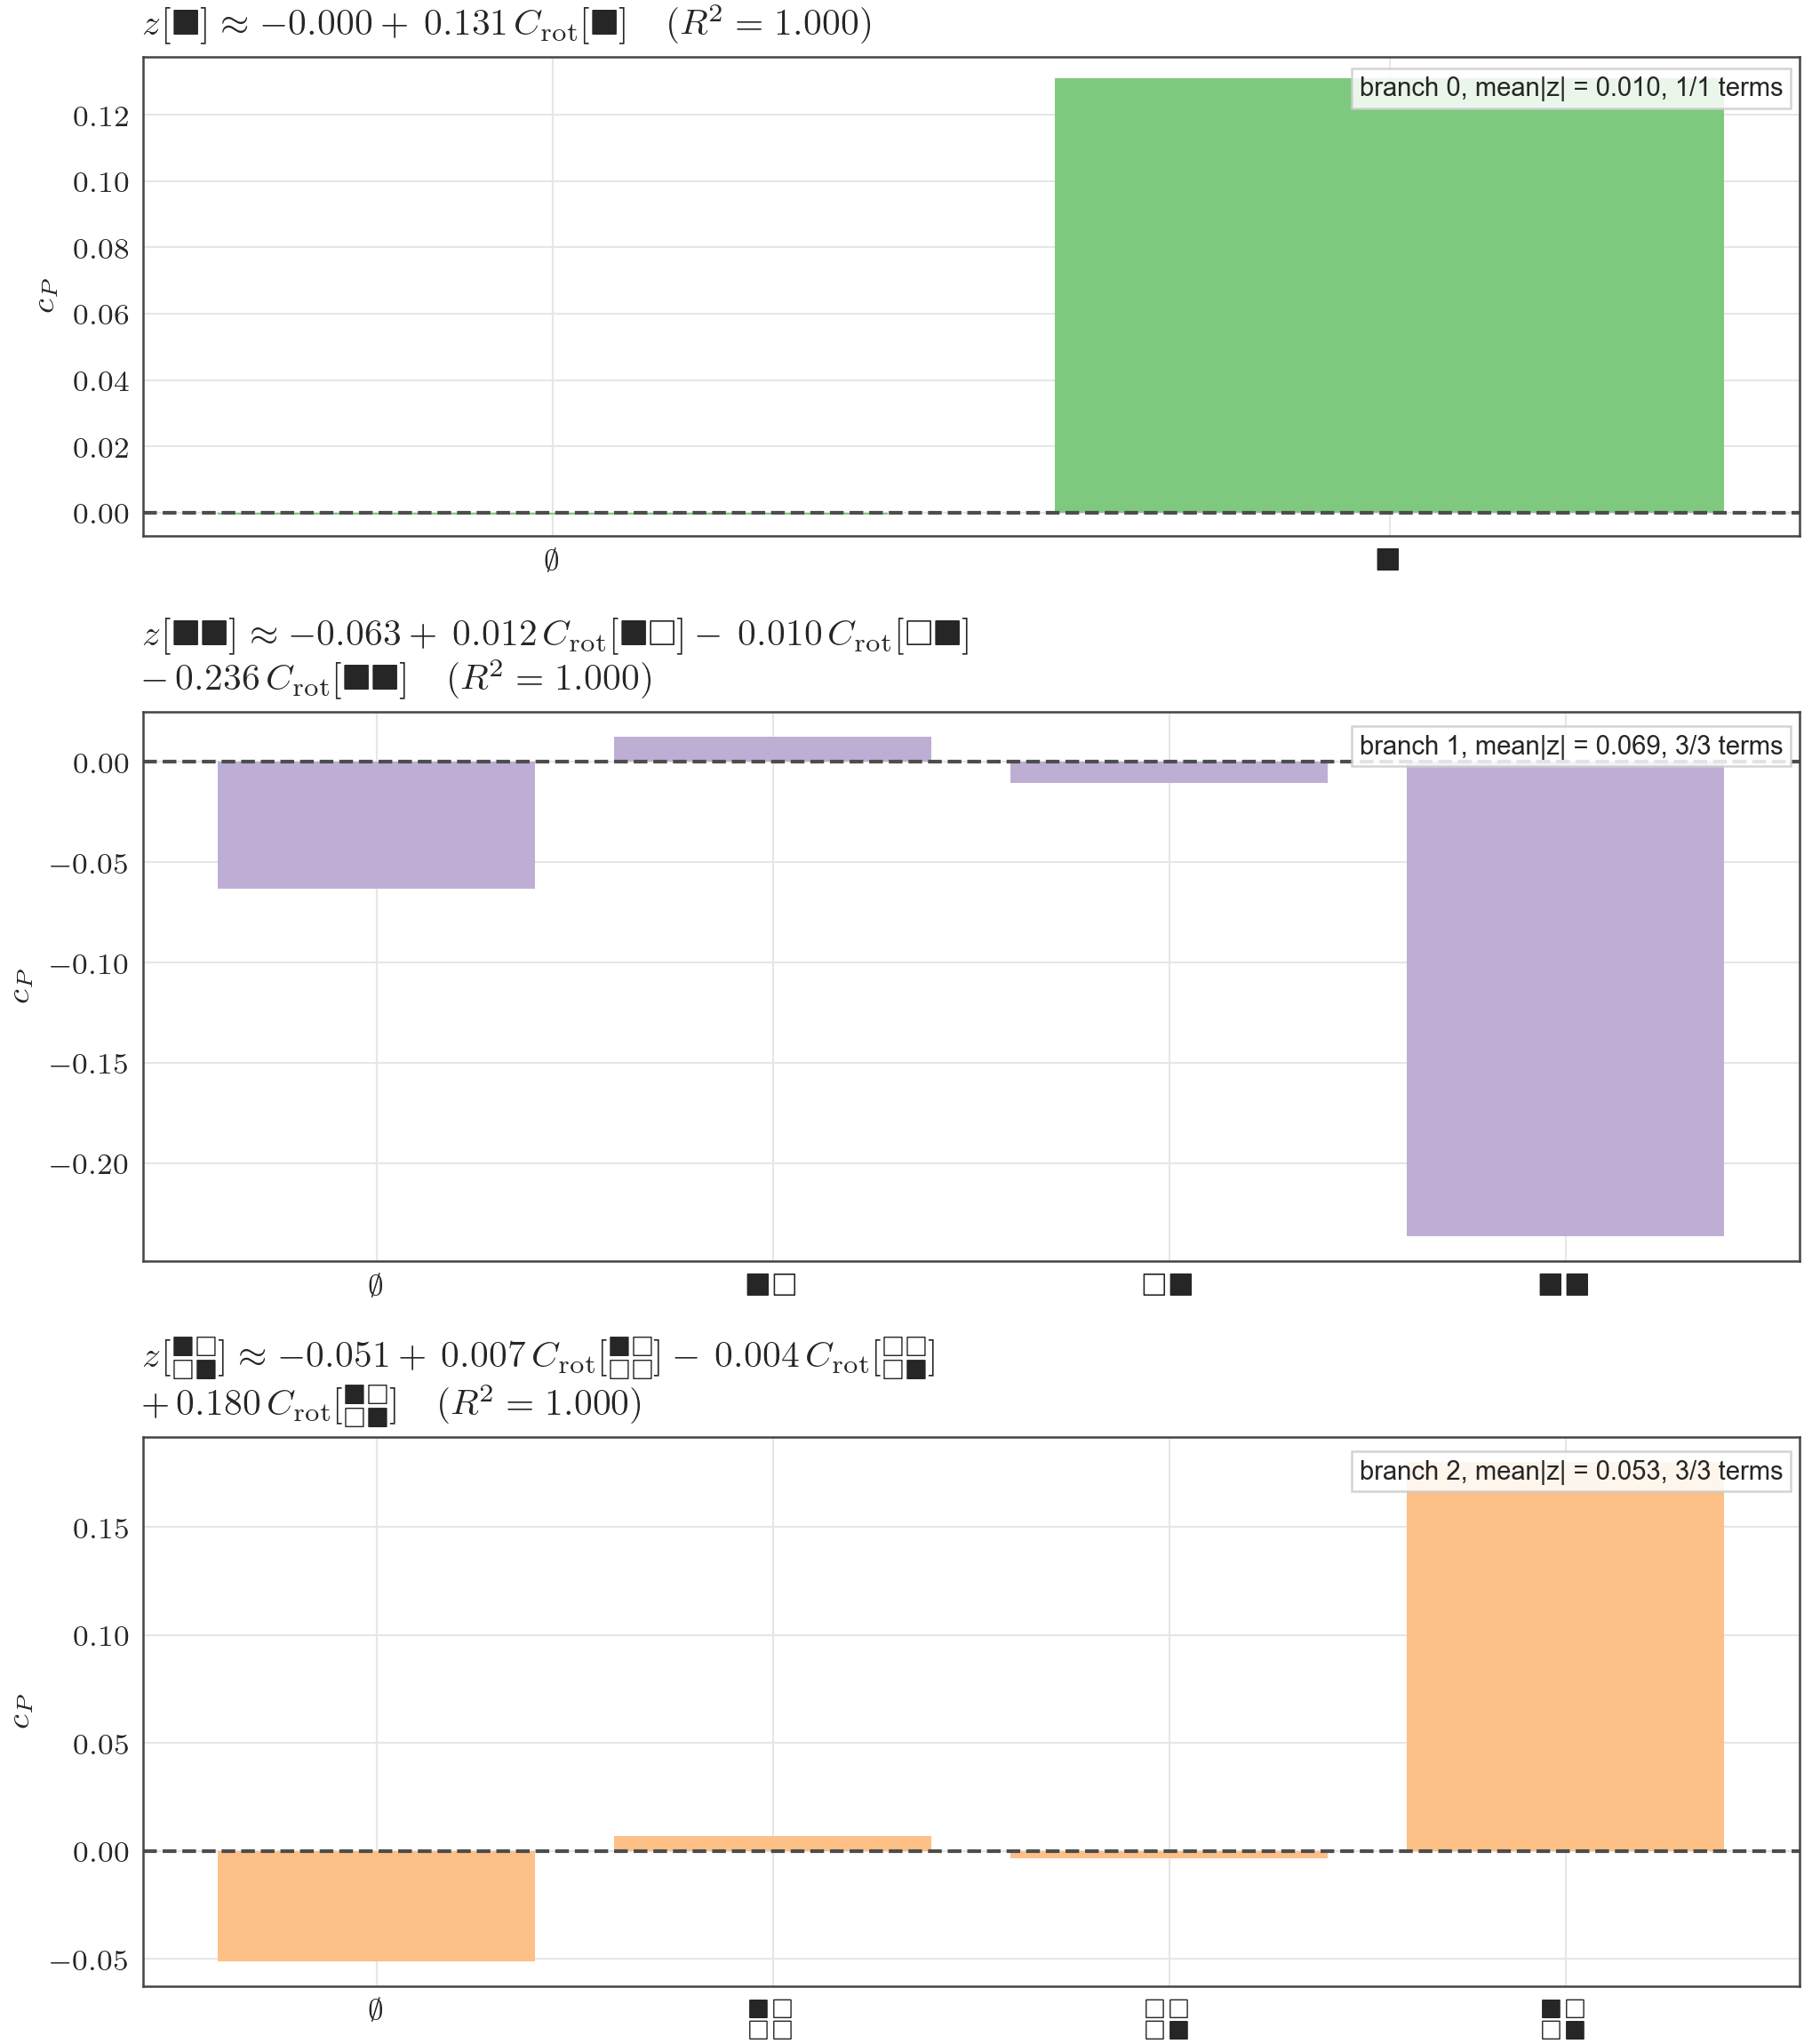

In [11]:
from tetriscnn.plots import get_active_branches, plot_branch_fits

net1 = ShapeAdaptiveConvNet(in_channels=1, kernels=cf.kernels, equivariant=cf.equivariant,
                            equivariant_group=cf.equivariant_group,
                            hidden_size=cf.hidden_size, init=cf.init, device=DEVICE).to(DEVICE)
net1.load_state_dict(torch.load(Path(cf.logdir) / "net1.pt", map_location=DEVICE))
net1.eval()

x_val = cf.val_dataset.data.to(DEVICE)
with torch.no_grad():
    z_val = net1(x_val).cpu().numpy()
snapshots = x_val.cpu().numpy()

# Active branches: those well above the learning-rate floor discussed above.
final_lr = metrics["learning_rate"][-1]
active, _ = get_active_branches(z_val, final_lr, floor_margin=1e3)
active_branches = [int(k) for k in np.flatnonzero(active)]
best = int(np.argmax(importance))
print(f"final learning rate {final_lr:.1e}; active branches: {active_branches}; strongest: {best}")

# Every active branch: the complete coefficient spectrum of its full fit, with the fitted
# equation as the panel title. An equivariant branch is linear in rotation-averaged
# correlators (written C_rot); plot_branch_fits passes cf.equivariant_group to the fit.
full_fits = plot_branch_fits(cf, snapshots, z_val, None, final_lr=final_lr, branches=active_branches,
                             channel_names=["Z"], max_bars=None, show_dont_save=True)


### The pruned fit

The full fit is exact but, for larger patterns, contains many terms. The quotable result is
the shortest equation that is nearly as good. `plot_branch_fits` finds it by forward
selection: it adds the most explanatory correlator first, then the best addition given that
one, and keeps the shortest prefix within `plateau_tol` of the best $R^2$ on the path (and
never below `plateau_floor`). The kept terms are outlined and the discarded ones faded. Each panel title is now the
unpenalised refit on the kept terms alone, as in `Figure5.ipynb`.


<repo>/tetriscnn/plots.py:298: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


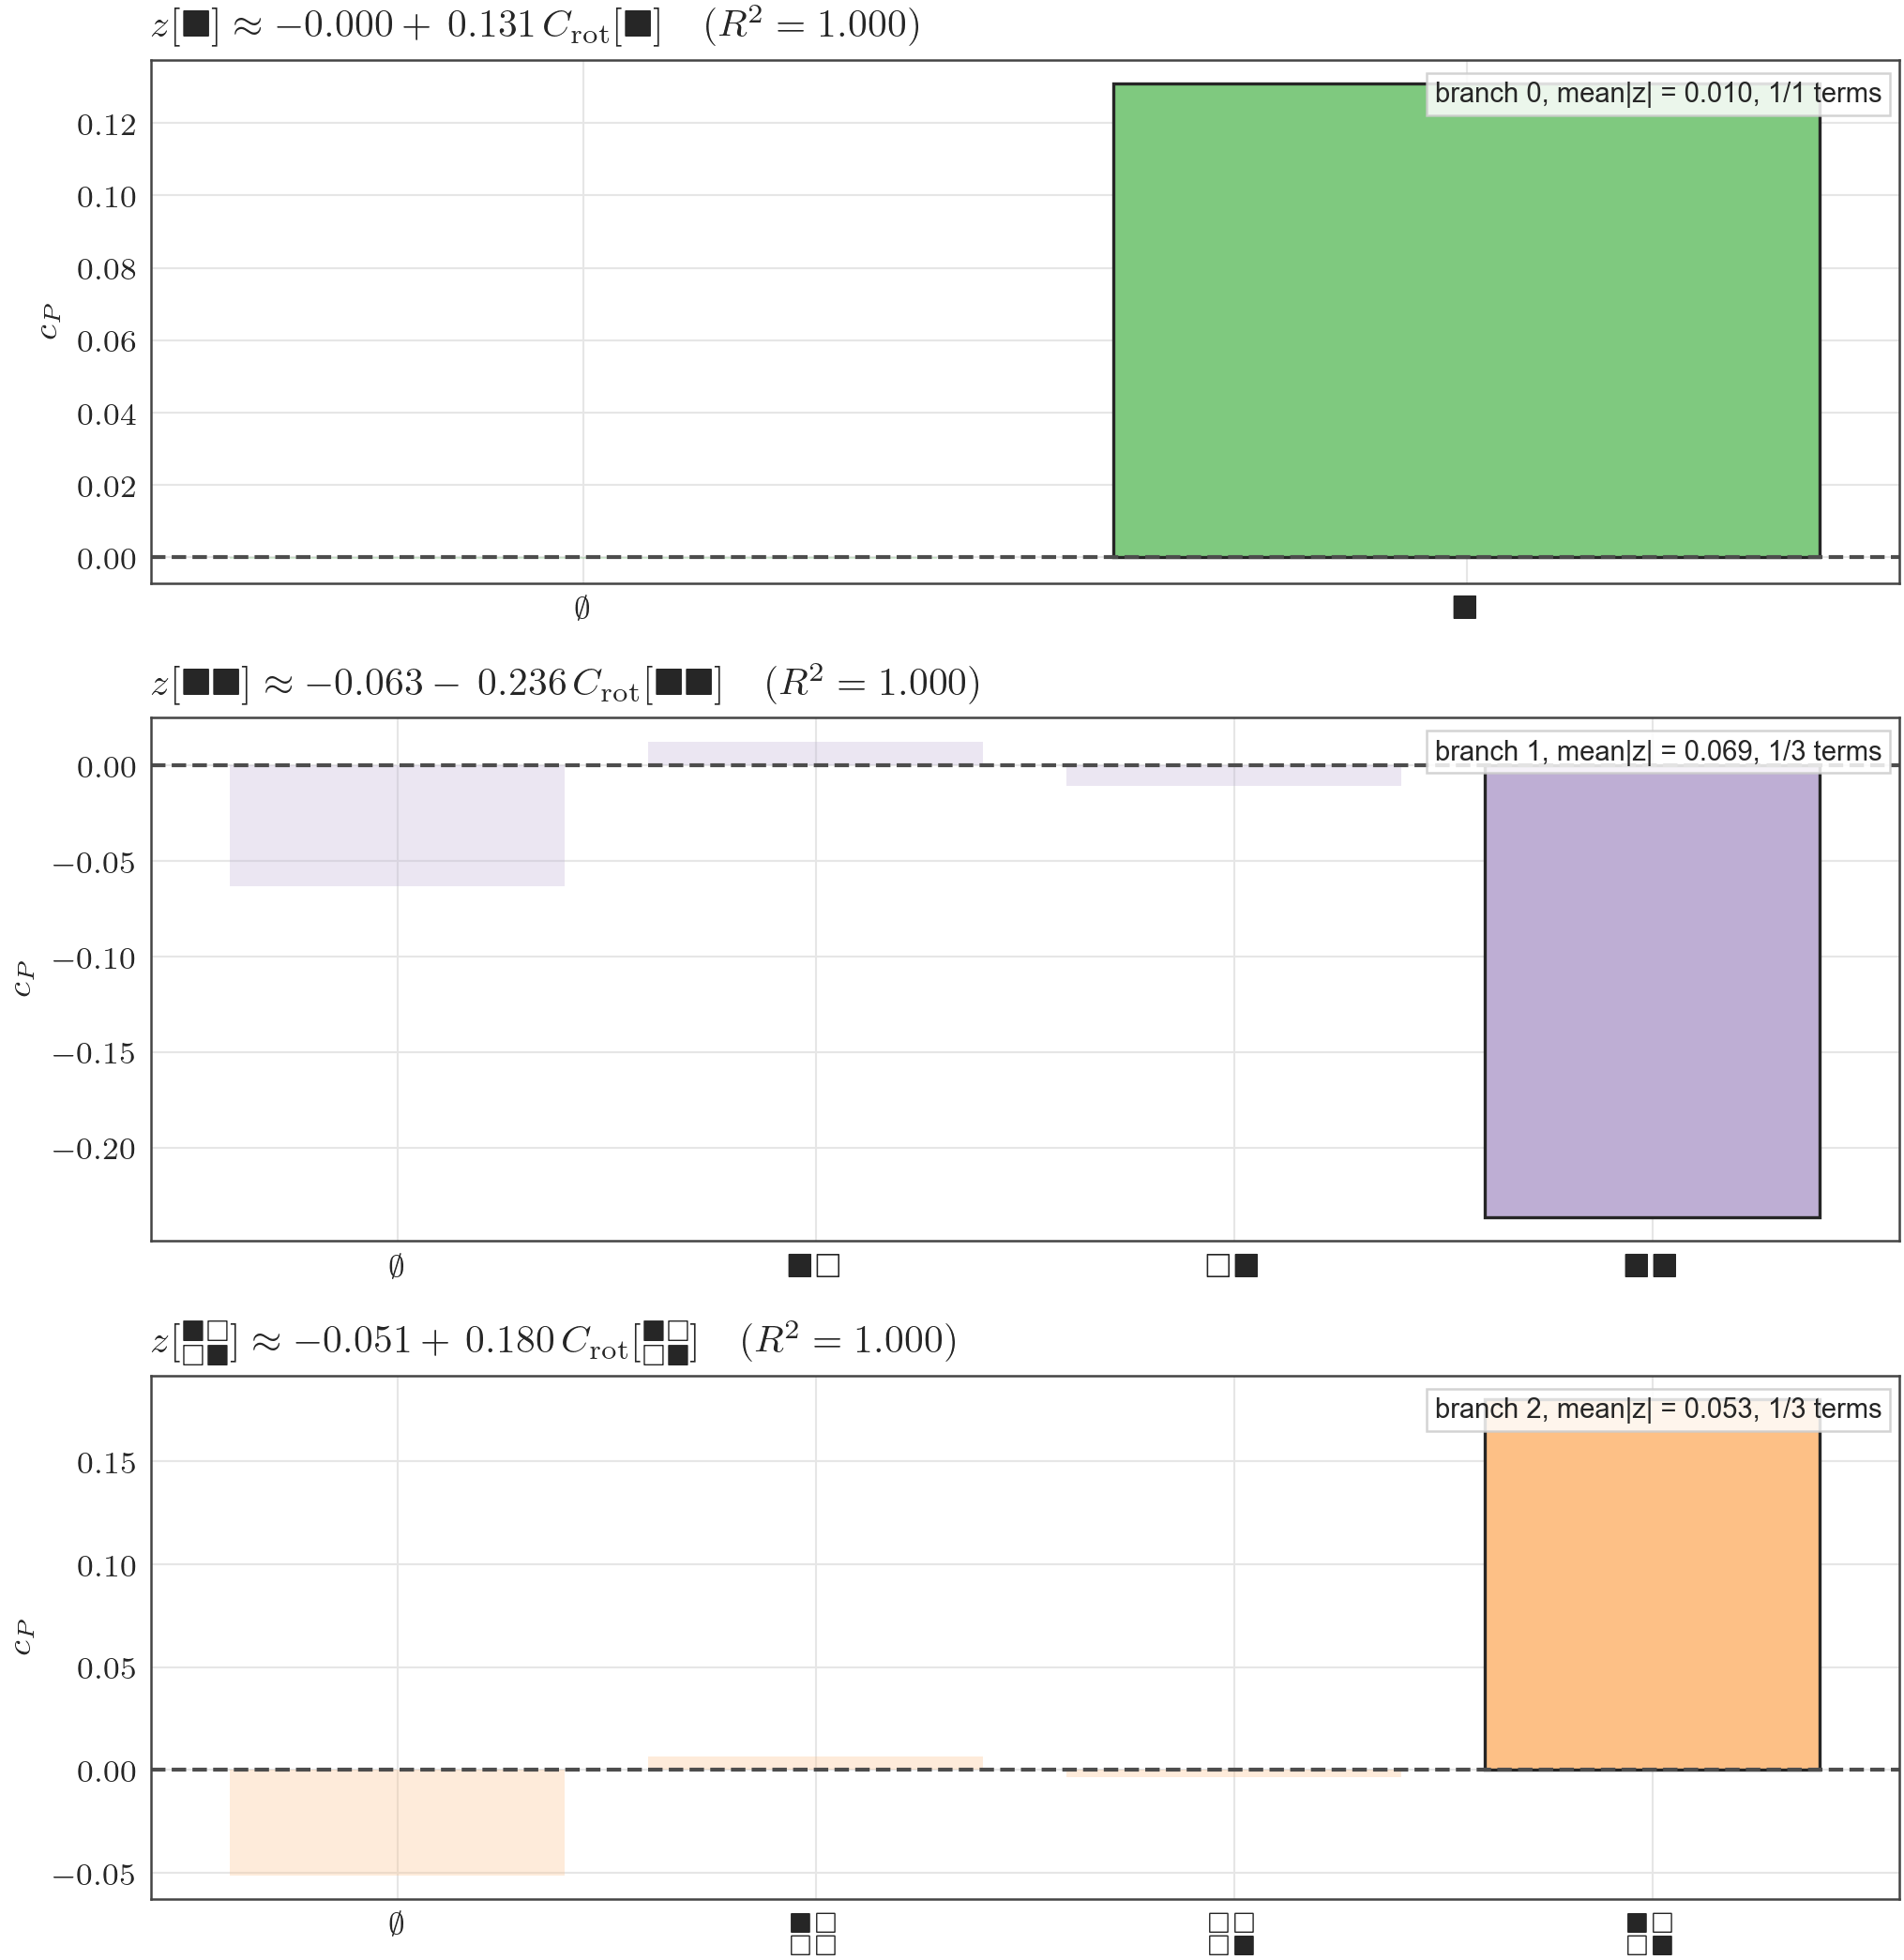

In [12]:
pruned_fits = plot_branch_fits(cf, snapshots, z_val, None, final_lr=final_lr, branches=active_branches,
                               channel_names=["Z"], max_bars=5, max_terms=3,
                               plateau_tol=0.01, plateau_floor=0.95, show_dont_save=True)


Each active branch reduces to a single correlator without losing anything: the single-site
branch to the magnetization, the nearest-neighbour branch to $C[\blacksquare\blacksquare]$,
and the diagonal branch to the diagonal correlator. The latter two have coefficients of
opposite sign, just as $-(1-2p)^2$ and $+(1-2p)^2$ do, so both branches report the same
Néel order. The single-site sub-terms seen in the full fit carry no weight.

For this toy dataset the pruning is easy, since each dictionary has at most three terms. On
the Rydberg data, with two measurement bases and up to 15 terms per branch, it is what turns
an exact but unreadable fit into a quotable equation (see `Figure5.ipynb`).

Averaging the strongest activation over all snapshots at each value of $p$ turns it into a
phase diagram. The branch follows the $(1-2p)^2$ curve of the ground-truth correlator from
step 1, and the classifier head then places its threshold on it.

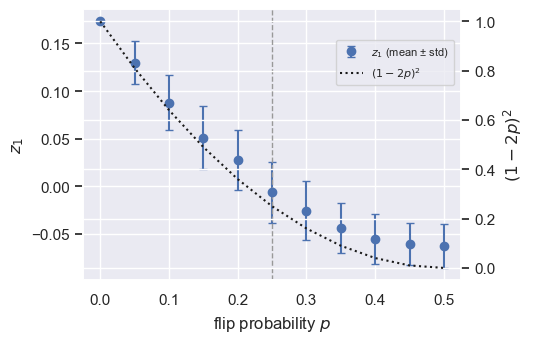

In [13]:
p_val = cf.val_dataset.times.cpu().numpy()
at_p = [np.isclose(p_val, p) for p in P_VALUES]      # times are stored as float32
z_mean = np.array([z_val[m, best].mean() for m in at_p])
z_std = np.array([z_val[m, best].std() for m in at_p])

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.errorbar(P_VALUES, z_mean, yerr=z_std, fmt="o", capsize=3, label=rf"$z_{{{best}}}$ (mean ± std)")
ax.set_xlabel("flip probability $p$")
ax.set_ylabel(rf"$z_{{{best}}}$")
ax.axvline(P_CRITICAL, color="0.6", ls="--", lw=1)

# the ground-truth correlator, mapped onto the activation scale by the fit above
ax2 = ax.twinx()
ax2.plot(P_VALUES, (1 - 2 * P_VALUES) ** 2, "k:", label=r"$(1-2p)^2$")
ax2.set_ylabel(r"$(1-2p)^2$")
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.88), fontsize=8)
fig.tight_layout()
plt.show()

## 6. Adapting this to your own data

**What to change.** Only the processor's file reading, and the name you register. The rest of
this notebook, and all of `main.py`, work unchanged once `cf.dataset` points at your name.

**Checklist for the processor.**

* Spins must be $\pm1$, not $0/1$. The branches' correlator reading assumes $\pm1$.
* A snapshot is `(C, H, W)`, even for a single basis (`C = 1`). Several bases measured on the
  same system go into separate channels, and cross-basis correlators then become available to
  the branches.
* Every pattern must fit on the lattice. `train()` checks this and names any branch that does
  not; for one-dimensional chains, store the chain as an `(N, 1)` image and use
  `kernel_set="chainkernels"`.
* `sample_times` must have one entry per snapshot, in the same order as `samples`.

**Data that comes pre-split.** If your train and validation sets are fixed in advance (for
instance, separate simulation seeds), expose `train_samples`/`val_samples` and
`train_times`/`val_times` instead of `samples`/`sample_times`. `create_datasets()` then uses
the split as given; the simulated TFIM and ILGT loaders in `tetriscnn/dataprocessing.py`
work this way.

**Other tasks on the same processor.** Setting `cf.task = "regression"` trains the network to
estimate $p$ from a snapshot (add `cf.normalize_labels = True` and `cf.goodness_str = "r2"`).
Setting `cf.task = "partition"` with a `cf.partition_index` runs one learning-by-confusion
split, as for the experimental data; `main.py` with `cf.task = "lbc"` loops over all of them.

**Sweeping the penalty.** A single $\lambda_{\max}$ is a single point on the regularisation
path. The manuscript's statements about which correlators matter rest on sweeping it
(`cf.experiment_name = "lambdamax"` in `main.py`) and over several seeds, which is what
`FiguresApp_F_lambdamax.ipynb` plots for the Rydberg data.